# PlantVG: Plant Voxel Generator

Turns a pair of microscope images — one **transverse** (cross-section) and one **longitudinal**
(lengthwise) — into a 3D model of the cells, saved as a TIFF stack you can open in ImageJ/FIJI or
use for finite element analysis.

You don't need to know any programming. Each step below is a box you fill in and a ▶ button you
press.

> **How to run a step:** hover over the grey box and click the **▶** button on its left, or press
> **Shift+Enter**. Wait for the ✓ to appear before moving to the next one.

> **First time?** You'll see a red warning that this notebook wasn't authored by Google. That's
> normal for any shared notebook. Click **Run anyway**.

> **Everything is measured in pixels**, not microns, because every microscope image has its own
> scale. Keep a note of your own pixels-per-micron conversion. *(The bundled Zea mays sample is
> 4.3 µm per pixel.)*

---

*Stubbs, C.J. & Benzecry, A. — Fairleigh Dickinson University.*
*Source: [github.com/cstubbsFDU/PlantVG](https://github.com/cstubbsFDU/PlantVG)*


## Step 1: Get started

Nothing to fill in. Press ▶ and wait about 20 seconds for the green ✓.


In [1]:
#@title ▶ Press play to set up PlantVG
import sys, os, time, urllib.request, traceback

CORE_URL = 'https://raw.githubusercontent.com/cstubbsFDU/PlantVG/main/plantvg_core.py'

print('Installing... (about 20 seconds)')
os.system('pip install -q tifffile')

import numpy as np
import matplotlib.pyplot as plt

try:
    urllib.request.urlretrieve(CORE_URL, 'plantvg_core.py')
except Exception:
    print('\nCould not download PlantVG automatically.')
    print('Please select the file plantvg_core.py from your computer:')
    from google.colab import files
    up = files.upload()
    if not up:
        raise SystemExit('No file selected. Run this step again.')
    os.rename(next(iter(up)), 'plantvg_core.py')

exec(open('plantvg_core.py').read())

def explain(err):
    """Show a readable message instead of a Python traceback."""
    print('\n' + '=' * 68)
    print('SOMETHING WENT WRONG\n')
    print(str(err))
    print('=' * 68)

def show_traces(mask, boundaries, title, keep=None, ax=None):
    ax = ax or plt.gca()
    ax.imshow(mask, cmap='gray')
    cm = plt.get_cmap('hsv')
    for i, b in enumerate(boundaries):
        if keep is not None and not keep[i]:
            continue
        ax.plot(b[:, 1], b[:, 0], lw=1.4, color=cm((i * 0.37) % 1.0))
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

print('\n\u2713 PlantVG is ready. Go to Step 2.')


Installing... (about 20 seconds)

✓ PlantVG is ready. Go to Step 2.


## Step 2: Choose your two images

You need **two** images of the same tissue:

- a **transverse** image — the cross-section, showing cells as closed shapes
- a **longitudinal** image — the lengthwise cut, showing how long the cells are

Both must already be **black and white** (segmented), not raw microscope photos. Any format works
— JPG, PNG, TIF.

Leave the box on `my own images` and press ▶, then click **Choose Files** and select **both**
images together *(hold Ctrl, or Cmd on a Mac, to pick two at once)*.

> Just want to see how it works first? Switch the box to `Zea mays sample` and press ▶. Nothing to
> upload; it loads an example maize stem for you.


Loaded the Zea mays sample.



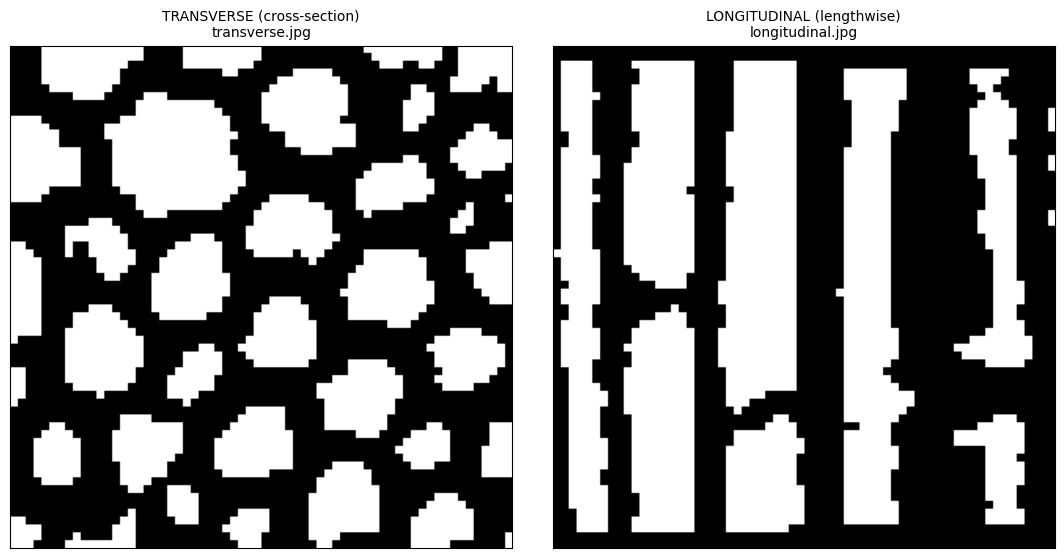

✓ Images loaded.

IMPORTANT: check the two titles above. If they are swapped, rename your files so the
cross-section one has "trans" in its name, then run this step again.


In [5]:
#@title ▶ Load images
images = "Zea mays sample"  #@param ["my own images", "Zea mays sample"]

SAMPLE = ('https://raw.githubusercontent.com/cstubbsFDU/PlantVG/main/Examples/Zea%20Mays%20-%20CT%20Scan/CT%20-%20Trans.jpg',
          'https://raw.githubusercontent.com/cstubbsFDU/PlantVG/main/Examples/Zea%20Mays%20-%20CT%20Scan/CT%20-%20Long.jpg')

transverse_path = longitudinal_path = None
try:
    if images == 'Zea mays sample':
        for url, name in zip(SAMPLE, ['transverse.jpg', 'longitudinal.jpg']):
            urllib.request.urlretrieve(url, name)
        transverse_path, longitudinal_path = 'transverse.jpg', 'longitudinal.jpg'
        print('Loaded the Zea mays sample.\n')
    else:
        from google.colab import files
        print('Select BOTH images at once (hold Ctrl / Cmd to pick two):')
        up = list(files.upload())
        if len(up) == 0:
            raise ValueError('No files were selected. Press play again and choose two images.')
        if len(up) != 2:
            raise ValueError(
                f'You selected {len(up)} file(s), but PlantVG needs exactly 2: one transverse\n'
                'image and one longitudinal image. Press play again and select both together\n'
                '(hold Ctrl, or Cmd on a Mac, while clicking).')
        guess = [f for f in up if any(k in f.lower() for k in ('trans', 'cross', 'xsec'))]
        transverse_path = guess[0] if guess else up[0]
        longitudinal_path = [f for f in up if f != transverse_path][0]

    _, _bw_t = read_binary_image(transverse_path)
    _, _bw_l = read_binary_image(longitudinal_path)

    fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
    ax[0].imshow(_bw_t, cmap='gray')
    ax[0].set_title(f'TRANSVERSE (cross-section)\n{transverse_path}', fontsize=10)
    ax[1].imshow(_bw_l, cmap='gray')
    ax[1].set_title(f'LONGITUDINAL (lengthwise)\n{longitudinal_path}', fontsize=10)
    for a in ax: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()

    print('\u2713 Images loaded.')
    print('\nIMPORTANT: check the two titles above. If they are swapped, rename your files so the')
    print('cross-section one has "trans" in its name, then run this step again.')
except Exception as e:
    explain(e)


## Step 3: Settings

| setting | what it means | typical |
|---|---|---|
| **Model height** | how tall the 3D model should be, in pixels | 100–300 |
| **Cell wall thickness** | how thick the walls are, in pixels | 4–10 |
| **Wall thickness variation** | random ± on that thickness, cell to cell. 0 = every wall identical | 0–2 |
| **End cap radius** | how rounded the tops and bottoms of cells are | 2–10 |
| **Cell length factor** | multiplies every measured cell length. 1.0 = use them as measured | 1.0 |
| **Downsample** | 1 = full detail. 2 = half size in every direction, so 8× smaller file | 1 or 2 |
| **Number of models** | how many different models to build from the same images | 1–20 |
| **Cell length distribution** | the statistical shape of the cell length spread | Normal |

> **Building several models?** Each one is a different random arrangement of cells drawn from the
> same measurements. That's the point; it lets you test how much natural variation in cell length
> changes the tissue's mechanical behaviour.

> **Which distribution?** If you don't have a reason to prefer another, leave it on `Normal`. With
> a small number of cells they all fit about equally well, so this is a judgement call based on
> what you know about your tissue, not something the data can settle.


In [13]:
#@title ▶ Settings
model_height = 256  #@param {type:"integer"}
cell_wall_thickness = 9  #@param {type:"integer"}
wall_thickness_variation = 0  #@param {type:"integer"}
end_cap_radius = 5  #@param {type:"integer"}
cell_length_factor = 1.0  #@param {type:"number"}
downsample = 2  #@param [1, 2, 3, 4] {type:"raw"}
number_of_models = 1  #@param {type:"integer"}
cell_length_distribution = "Normal"  #@param ["Normal", "Exponential", "Gamma", "Poisson", "Weibull"]
output_file_name = "My Voxel Model"  #@param {type:"string"}
#@markdown ---
#@markdown Leave this alone unless you want to reproduce an earlier run exactly.
random_seed = 0  #@param {type:"integer"}

try:
    params = Parameters(
        voxel_depth=model_height, wall_thickness=cell_wall_thickness,
        wall_variation=wall_thickness_variation, radius=end_cap_radius,
        length_factor=cell_length_factor, output_name=output_file_name,
        dsf=int(downsample), n_models=number_of_models,
        distribution=cell_length_distribution,
        seed=None if random_seed < 0 else random_seed)

    problems = params.validate()
    if problems:
        raise ValueError('Please fix these settings:\n  - ' + '\n  - '.join(problems))

    d, h, w = params.output_shape(_bw_t.shape)
    mb = d * h * w / 1e6
    print(f'Each model will be {h} x {w} pixels across and {d} slices tall.')
    print(f'File size: about {mb:.0f} MB each, {number_of_models} model(s) '
          f'= {mb * number_of_models:.0f} MB total.')
    if mb * number_of_models > 500:
        print('\n\u26a0 That is a lot of data. Consider raising Downsample or building '
              'fewer models.')
    print('\n\u2713 Settings accepted. Go to Step 4.')
except Exception as e:
    explain(e)


Each model will be 115 x 115 pixels across and 129 slices tall.
File size: about 2 MB each, 1 model(s) = 2 MB total.

✓ Settings accepted. Go to Step 4.


## Step 4: Check the cell outlines

**This is the one step where you have to make a judgement.** PlantVG has to know which parts of
your image are *cells* and which parts are *wall*. It guesses, and sometimes it guesses backwards.

Press ▶, then look at the picture. You want **one coloured outline around each cell**:

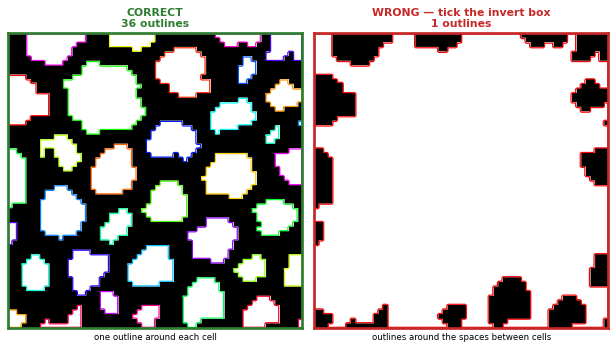

If yours looks like the picture on the right, outlines around the *gaps between* cells rather
than the cells themselves, tick **swap cells and walls** and press ▶ again.


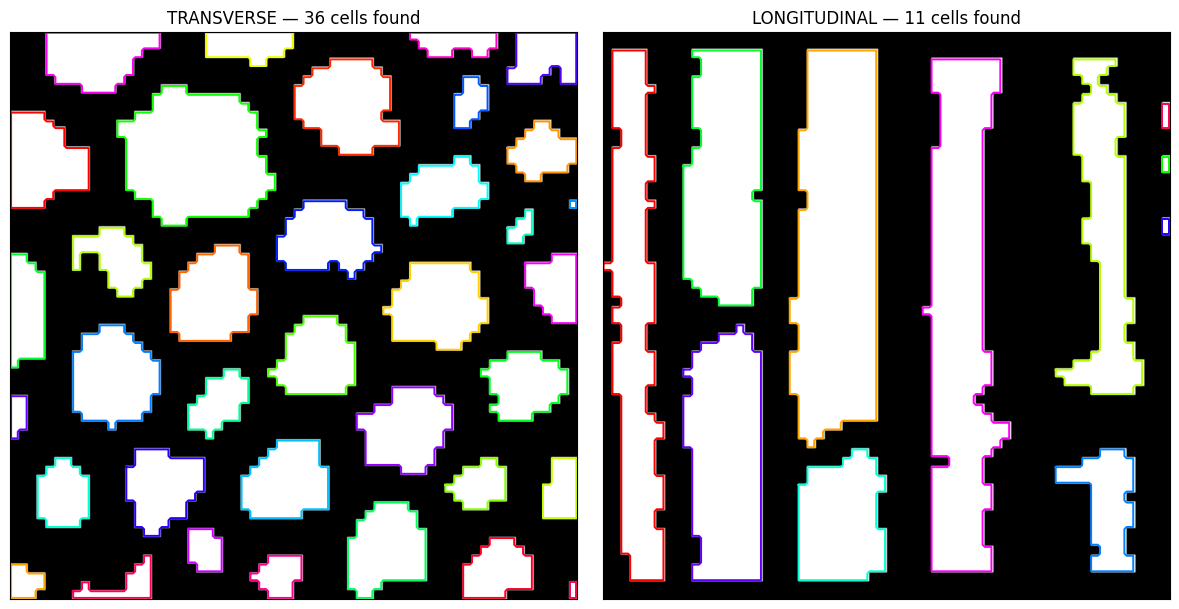

✓ 36 cells outlined in the cross-section.
  If each cell has exactly one outline, go to Step 5.


In [14]:
#@title ▶ Check the outlines
swap_cells_and_walls_transverse = False  #@param {type:"boolean"}
swap_cells_and_walls_longitudinal = False  #@param {type:"boolean"}

try:
    prepared = prepare_images(transverse_path, longitudinal_path,
                              swap_cells_and_walls_transverse,
                              swap_cells_and_walls_longitudinal)

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    show_traces(prepared.transverse, prepared.boundaries,
                f'TRANSVERSE — {prepared.n_cells} cells found', ax=ax[0])
    show_traces(prepared.longitudinal, prepared.boundaries_long,
                f'LONGITUDINAL — {len(prepared.boundaries_long)} cells found', ax=ax[1])
    plt.tight_layout(); plt.show()

    if prepared.n_cells < 5:
        print(f'\u26a0 Only {prepared.n_cells} cells found in the transverse image. That is very')
        print('  few. Try ticking "swap cells and walls" above, or check that your image is')
        print('  properly black and white.')
    elif prepared.n_cells > 2000:
        print(f'\u26a0 {prepared.n_cells} cells found -- that is unusually many, which often means')
        print('  the image is speckled with noise. Building the model may be slow.')
    else:
        print(f'\u2713 {prepared.n_cells} cells outlined in the cross-section.')
        print('  If each cell has exactly one outline, go to Step 5.')
except Exception as e:
    explain(e)


## Step 5: Choose which cell lengths to keep

PlantVG measures how long each cell is in the longitudinal image, and shows you the spread.

Cells that run off the top or bottom of the image are **dropped automatically**; you can't tell
how long they really are, so including them would make your cells look shorter than they are.

Press ▶, then **drag the blue slider** to exclude anything that obviously isn't a whole cell,
usually a few tiny fragments at the left end. The count updates as you drag. When you're happy,
move to Step 6.


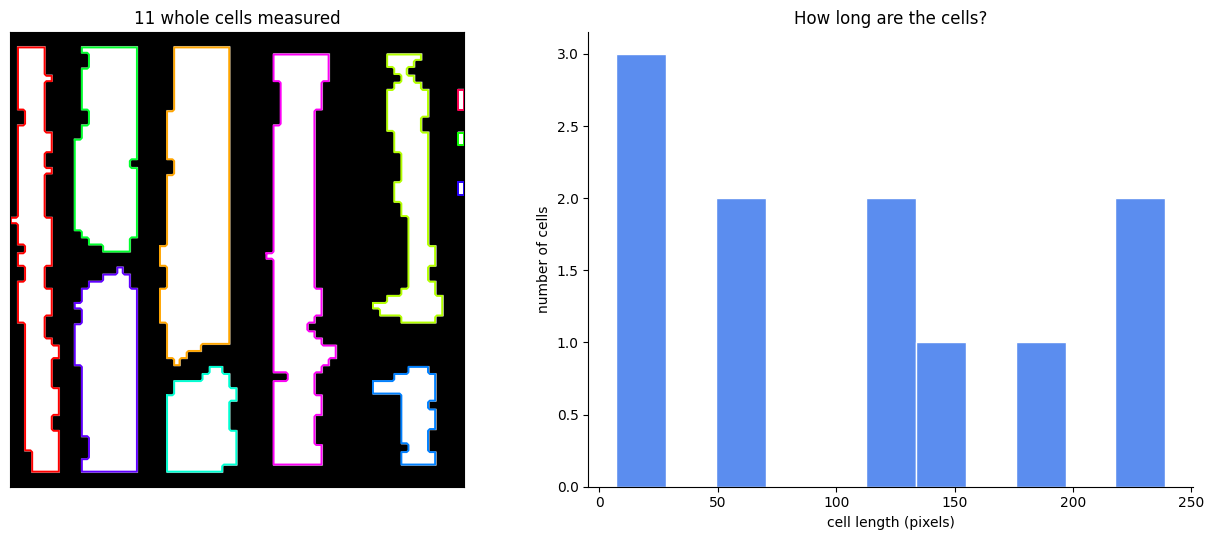

FloatRangeSlider(value=(-4.600000000000001, 250.6), continuous_update=False, description='Keep cells between:'…

Output()


Drag the slider, then go to Step 6.


In [15]:
#@title ▶ Measure the cells
try:
    raw_heights, counted = cell_heights(prepared.boundaries_long,
                                        prepared.longitudinal.shape[0])
    if raw_heights.size == 0:
        raise ValueError(
            f'None of the {len(prepared.boundaries_long)} cells in your longitudinal image\n'
            'can be measured -- every one runs off the top or bottom edge, so its true\n'
            'length is unknown.\n\n'
            'Try a longitudinal image with some blank space above and below the cells.')

    scaled = params.length_factor * raw_heights
    dropped = (~counted).sum()

    fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
    show_traces(prepared.longitudinal, prepared.boundaries_long,
                f'{counted.sum()} whole cells measured'
                + (f'  ({dropped} cut off by the edge, ignored)' if dropped else ''),
                keep=counted, ax=ax[0])
    ax[1].hist(scaled, bins=min(12, max(3, scaled.size)),
               color='#5B8DEF', edgecolor='white')
    ax[1].set_xlabel('cell length (pixels)'); ax[1].set_ylabel('number of cells')
    ax[1].set_title('How long are the cells?')
    for s in ('top', 'right'): ax[1].spines[s].set_visible(False)
    plt.tight_layout(); plt.show()

    lo, hi = float(scaled.min()), float(scaled.max())
    pad = max(1.0, 0.05 * (hi - lo))
    FILTER = (lo - pad, hi + pad)

    if scaled.size < 4:
        print(f'\u26a0 Only {scaled.size} whole cells could be measured. PlantVG will still run,')
        print('  but the cell length statistics will be very rough. More cells is better.')

    import ipywidgets as W
    from IPython.display import display
    slider = W.FloatRangeSlider(
        value=FILTER, min=lo - pad, max=hi + pad, step=max(0.1, (hi - lo) / 200),
        description='Keep cells between:', continuous_update=False,
        readout_format='.0f', style={'description_width': '160px'},
        layout=W.Layout(width='95%'))
    out = W.Output()
    def _on_change(change):
        global FILTER
        FILTER = tuple(float(v) for v in change['new'])
        kept = ((scaled > FILTER[0]) & (scaled < FILTER[1])).sum()
        with out:
            out.clear_output()
            print(f'   keeping {kept} of {scaled.size} cells'
                  + ('   \u26a0 too few, widen the slider' if kept < 2 else ''))
    slider.observe(_on_change, names='value')
    display(slider, out); _on_change({'new': slider.value})
    print('\nDrag the slider, then go to Step 6.')
except Exception as e:
    explain(e)


## Step 6: Build the models

Press ▶. This usually takes a few seconds per model. You'll get a preview of the finished model
underneath.


Using 8 cells. Average length 143 pixels (± 70).
Fitted a Normal distribution.

  model 1 of 1: end caps...
  model 1 of 1: voxel matrix...
  model 1 of 1: writing tiff...

✓ Built 1 model(s) in 0.3 seconds:
     My Voxel Model-1.tiff   (1.7 MB)


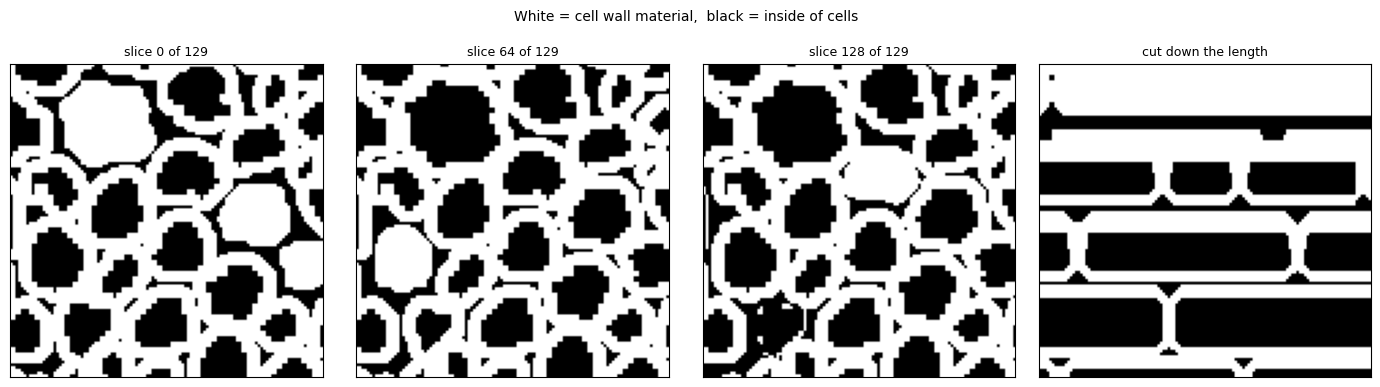

Go to Step 7 to save your models.


In [16]:
#@title ▶ Build
try:
    lengths = analyze_lengths(prepared, FILTER[0], FILTER[1],
                              params.length_factor, params.distribution)
    print(f'Using {lengths.heights.size} cells. '
          f'Average length {lengths.avg:.0f} pixels (\u00b1 {lengths.std:.0f}).')
    print(f'Fitted a {lengths.fitted.name} distribution.\n')

    t0 = time.time()
    def _progress(i, n, stage):
        print(f'  model {i} of {n}: {stage}...', flush=True)
    paths = generate_models(prepared, lengths, params, output_dir='.', progress=_progress)
    print(f'\n\u2713 Built {len(paths)} model(s) in {time.time() - t0:.1f} seconds:')
    for p in paths:
        print(f'     {p.name}   ({p.stat().st_size / 1e6:.1f} MB)')

    import tifffile
    vol = tifffile.imread(str(paths[0])) > 0
    d, h, w = vol.shape
    fig, axs = plt.subplots(1, 4, figsize=(14, 3.9))
    for ax, k in zip(axs[:3], np.linspace(0, d - 1, 3).astype(int)):
        ax.imshow(vol[k], cmap='gray'); ax.set_title(f'slice {k} of {d}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    axs[3].imshow(vol[:, :, w // 2].T, cmap='gray', aspect='auto')
    axs[3].set_title('cut down the length', fontsize=9)
    axs[3].set_xticks([]); axs[3].set_yticks([])
    plt.suptitle('White = cell wall material,  black = inside of cells', fontsize=10)
    plt.tight_layout(); plt.show()
    print('Go to Step 7 to save your models.')
except Exception as e:
    explain(e)


## Step 7: Save your models

Press ▶ to download the TIFF files to your computer. Open them in **ImageJ/FIJI** with
*File → Open*.

> Your browser may ask permission to download several files at once; say yes.

> **Don't leave this page without saving.** Colab throws away everything when you close the tab.


In [17]:
#@title ▶ Save
save_to = "my computer"  #@param ["my computer", "my Google Drive"]
drive_folder = "/content/drive/MyDrive/PlantVG output"  #@param {type:"string"}

try:
    if save_to == 'my computer':
        from google.colab import files
        for p in paths:
            files.download(str(p))
        print(f'\u2713 Downloading {len(paths)} file(s) to your Downloads folder.')
    else:
        import shutil
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        os.makedirs(drive_folder, exist_ok=True)
        for p in paths:
            shutil.copy(str(p), drive_folder)
        print(f'\u2713 Saved {len(paths)} file(s) to {drive_folder}')
except Exception as e:
    explain(e)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloading 1 file(s) to your Downloads folder.
